# Q1: Setup & Exploration

**Phase 1-2:** Project Setup, Data Exploration  
**Points: 6 points**

**Focus:** Load data, perform initial inspection, identify data quality issues.

**Lecture Reference:** See **Lecture 11, Notebook 1** (`11/demo/01_setup_exploration_cleaning.ipynb`), Phases 1-2 for examples of data loading, inspection, and initial visualizations.

In [91]:

# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# Create output directory
os.makedirs('output', exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

#1) Load the data
df = pd.read_csv('data/beach_sensors.csv')

In [92]:
#1) Load the dataset:
df = pd.read_csv('data/beach_sensors.csv')

#2) Inspect the data:
print("=== Inspecting Data ===")
print("Shape of DataFrame:", df.shape)
print("Info of DataFrame:", df.info) # count of non-null values and data types
print("Head of DataFrame:", df.head) # Display the first few rows of the dataframe
print("Describe DataFrame:", df.describe) # Get summary statistics of the dataframe

=== Inspecting Data ===
Shape of DataFrame: (195892, 18)
Info of DataFrame: <bound method DataFrame.info of                        Station Name   Measurement Timestamp  Air Temperature  \
0       63rd Street Weather Station  09/27/2018 10:00:00 AM            16.40   
1       63rd Street Weather Station  09/27/2018 11:00:00 AM            17.10   
2       63rd Street Weather Station  09/27/2018 01:00:00 PM            18.20   
3            Foster Weather Station  09/27/2018 01:00:00 PM            17.89   
4       63rd Street Weather Station  09/27/2018 03:00:00 PM            19.50   
...                             ...                     ...              ...   
195887   Oak Street Weather Station  11/24/2025 10:00:00 AM             9.80   
195888       Foster Weather Station  11/24/2025 11:00:00 AM             9.89   
195889   Oak Street Weather Station  11/24/2025 11:00:00 AM            10.80   
195890       Foster Weather Station  11/24/2025 12:00:00 PM            10.50   
195891   Oak

In [93]:
# Find possible datetime columns
datetime_cols = df.select_dtypes(include=['object']).columns
print(f"\nObject columns (potential datetime): {list(datetime_cols)}")


Object columns (potential datetime): ['Station Name', 'Measurement Timestamp', 'Measurement Timestamp Label', 'Measurement ID']


In [94]:
#3) Parse datetime (if applicable):
#   - Identify datetime column(s)
#   - Parse using `pd.to_datetime()`
#   - Check date range# Parse datetime column if applicable

# Parse datetime - adjust column name based on your actual data
# Common names: 'Measurement Timestamp', 'timestamp', 'date', 'datetime'
datetime_col = 'Measurement Timestamp'  # Update this based on actual column name
df[datetime_col] = pd.to_datetime(df[datetime_col])

# Set datetime as index for time series operations
df_indexed = df.set_index(datetime_col)

# Start and End Dates
start_date = df_indexed.index.min()
end_date = df_indexed.index.max()

print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Column names:
['Station Name', 'Measurement Timestamp', 'Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life', 'Measurement Timestamp Label', 'Measurement ID']

Data types:
Station Name                           object
Measurement Timestamp          datetime64[ns]
Air Temperature                       float64
Wet Bulb Temperature                  float64
Humidity                                int64
Rain Intensity                        float64
Interval Rain                         float64
Total Rain                            float64
Precipitation Type                    float64
Wind Direction                          int64
Wind Speed                            float64
Maximum Wind Speed                    float64
Barometric Pressure                   float64
Solar Radiation                   

In [95]:
#4. **Identify missing values:**
#   - Count missing values per column: `df.isnull().sum()`
#   - Calculate percentages
missing_values = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("\nMissing values:")
for col in df.columns:
    if missing_values[col] > 0:
        print(f"  {col}: {missing_values[col]} ({missing_percentages[col]:.1f}%)")


Missing values:
  Air Temperature: 75 (0.0%)
  Wet Bulb Temperature: 75736 (38.7%)
  Rain Intensity: 75736 (38.7%)
  Total Rain: 75736 (38.7%)
  Precipitation Type: 75736 (38.7%)
  Barometric Pressure: 146 (0.1%)
  Heading: 75736 (38.7%)


In [96]:
# Step 7: Get numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Step 8: Calculate statistics for numeric columns
stats_df = df[numeric_cols].describe().T
stats_df['missing_count'] = df[numeric_cols].isnull().sum()
stats_df = stats_df[['mean', 'std', 'min', 'max', 'missing_count']]
stats_df['column_name'] = stats_df.index
stats_df = stats_df[['column_name', 'mean', 'std', 'min', 'max', 'missing_count']]
stats_df = stats_df.reset_index(drop=True)


Numeric columns: ['Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life']


In [97]:
# SAVE ARTIFACT 1: q1_data_info.txt
with open('output/q1_data_info.txt', 'w') as f:
    f.write(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n\n")
    
    f.write("Column Names:\n")
    for col in df.columns:
        f.write(f"- {col}\n")
    
    f.write("\nData Types:\n")
    for col, dtype in df.dtypes.items():
        f.write(f"- {col}: {dtype}\n")
    
    f.write(f"\nDate Range:\n")
    f.write(f"Start: {start_date}\n")
    f.write(f"End: {end_date}\n")
    
    f.write("\nMissing Values:\n")
    for col in df.columns:
        count = missing_values[col]
        pct = missing_percentages[col]
        f.write(f"- {col}: {count} ({pct:.1f}%)\n")

print("\n✓ Saved: output/q1_data_info.txt")


✓ Saved: output/q1_data_info.txt


In [98]:
# SAVE ARTIFACT 2: q1_exploration.csv
stats_df.to_csv('output/q1_exploration.csv', index=False)
print("✓ Saved: output/q1_exploration.csv")

✓ Saved: output/q1_exploration.csv


✓ Saved: output/q1_visualizations.png


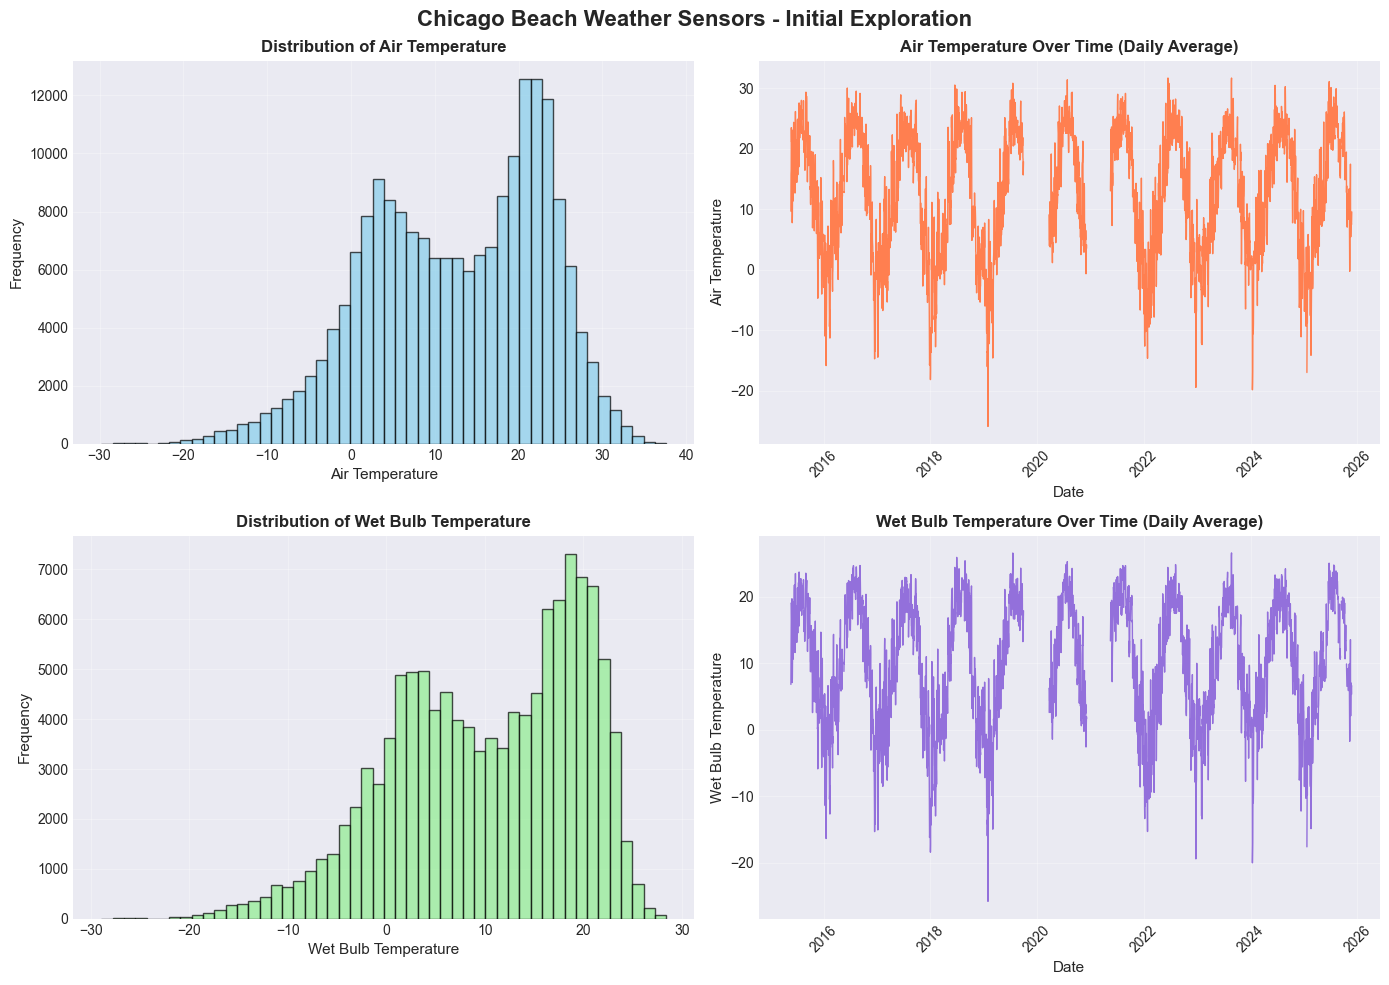

In [99]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chicago Beach Weather Sensors - Initial Exploration', fontsize=16, fontweight='bold')

# Plot 1: Distribution plot (histogram) - choose first numeric column
if len(numeric_cols) > 0:
    col1 = numeric_cols[0]
    axes[0, 0].hist(df[col1].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel(col1, fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title(f'Distribution of {col1}', fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)

# Plot 2: Time series plot - first numeric variable over time
if len(numeric_cols) > 0:
    # Resample to daily average for clearer visualization
    daily_avg = df_indexed[col1].resample('D').mean()
    axes[0, 1].plot(daily_avg.index, daily_avg.values, linewidth=1, color='coral')
    axes[0, 1].set_xlabel('Date', fontsize=11)
    axes[0, 1].set_ylabel(col1, fontsize=11)
    axes[0, 1].set_title(f'{col1} Over Time (Daily Average)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Distribution of second numeric column (if available)
if len(numeric_cols) > 1:
    col2 = numeric_cols[1]
    axes[1, 0].hist(df[col2].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel(col2, fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title(f'Distribution of {col2}', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Plot 4: Time series of second numeric column (if available)
if len(numeric_cols) > 1:
    daily_avg2 = df_indexed[col2].resample('D').mean()
    axes[1, 1].plot(daily_avg2.index, daily_avg2.values, linewidth=1, color='mediumpurple')
    axes[1, 1].set_xlabel('Date', fontsize=11)
    axes[1, 1].set_ylabel(col2, fontsize=11)
    axes[1, 1].set_title(f'{col2} Over Time (Daily Average)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

# Adjust layout and save
plt.tight_layout()
plt.savefig('output/q1_visualizations.png', dpi=150, bbox_inches='tight')
print("✓ Saved: output/q1_visualizations.png")
plt.show()

In [100]:
# 6. **Save artifacts:**
#    - Write data info to `output/q1_data_info.txt`
#    - Write exploration stats to `output/q1_exploration.csv`

with open('output/q1_data_info.txt', 'w') as f:
    f.write(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n\n")
    
    f.write("Column Names:\n")
    for col in df.columns:
        f.write(f"- {col}\n")
    
    f.write("\nData Types:\n")
    for col, dtype in df.dtypes.items():
        f.write(f"- {col}: {dtype}\n")
    
    f.write(f"\nDate Range:\n")
    f.write(f"Start: {start_date}\n")
    f.write(f"End: {end_date}\n")
    
    f.write("\nMissing Values:\n")
    for col in df.columns:
        count = missing_values[col]
        pct = missing_percentages[col]
        f.write(f"- {col}: {count} ({pct:.1f}%)\n")

print("\n✓ Saved: output/q1_data_info.txt")

# ========================================
# SAVE ARTIFACT 2: q1_exploration.csv
# ========================================
stats_df.to_csv('output/q1_exploration.csv', index=False)
print("✓ Saved: output/q1_exploration.csv")


✓ Saved: output/q1_data_info.txt
✓ Saved: output/q1_exploration.csv


In [101]:
## Decision Points

# - **Visualization choices:** What types of plots best show your data? See Lecture 11 Notebook 1 for examples.
# - **Data quality assessment:** What issues do you see? Missing data patterns? Outliers? Inconsistent formats? Document these for Q2.
